In [12]:
import mdtraj as md
import os
import glob
import pandas as pd

In [13]:
output_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/single_conformation/nmr'

In [14]:
ref_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/single_conformation/nma'

In [15]:
ref_name_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/Apo_holo_data/pdbs'

In [16]:
def generate_rmsd_alphaSAXS(pdb_id,ref_path,output_path):
    rmsd=[]
    ref_t=md.load(os.path.join(ref_path,pdb_id+'.pdb'))
    ref_atom=ref_t.topology.select('name CA')
    test_t = md.load(os.path.join(output_path, pdb_id+'.pdb'))
    test_atom=test_t.topology.select('name CA')
    if len(test_atom)!=len(ref_atom):
        return pdb_id+' has the wrong length'
    ca_selection=md.rmsd(test_t,ref_t,0,test_atom,ref_atom)
    return ca_selection[0]*10

In [17]:
pdb_list=[ f[:-4] for f in os.listdir(ref_name_path) if f.endswith('.pdb')]

In [18]:
len(pdb_list)

80

In [19]:
result={}

In [20]:
for i in pdb_list:
    try:
        result[i]=generate_rmsd_alphaSAXS(i,ref_path,output_path)
    except:
        print(f'{i} is not in the prediction dataset')

In [21]:
result

{'2K8R-1_A': 1.134001836180687,
 '1XSA-23_A': 1.7454659938812256,
 '1K2H-4_A': 1.9461485743522644,
 '2D9E-12_A': 1.0605955123901367,
 '1P7M-18_A': 1.1137987673282623,
 '1EX6_B': 3.54181170463562,
 '2AI6-18_A': 1.9164812564849854,
 '1MO8-14_A': 17.102670669555664,
 '2KXL-8_A': 2.4434663355350494,
 '1TJD_A': 1.1358267813920975,
 '2VCD-8_A': 1.2265419960021973,
 '2F63-4_A': 1.0343559086322784,
 '1ROE-10_A': 0.6840969622135162,
 '1CZ2-8_A': 0.9254506230354309,
 '1PUN-7_A': 1.4964541792869568,
 '1WCW_A': 1.8316690623760223,
 '1ZFS-13_B': 2.068326324224472,
 '1VHL_A': 1.5316592156887054,
 '2LKC-4_A': 4.066018164157867,
 '1ZOL_A': 2.0329488813877106,
 '1NTR-7_A': 1.7541404068470001,
 '1UR6-4_A': 0.7096786797046661,
 '1TNQ-33_A': 2.3796726763248444,
 '1S2O_A': 1.71100452542305,
 '1JM4-15_B': 5.279218554496765,
 '1RRO_A': 1.049409732222557,
 '2CG6_A': 1.8286554515361786,
 '1MO7-3_A': 16.396321058273315,
 '1VIY_C': 1.634029746055603,
 '1RTP_1': 0.8794058114290237,
 '1JKN-15_A': 1.770443320274353

In [22]:
df = pd.DataFrame(result.items(), columns=['Key', 'Value'])

In [23]:
df.describe()

,Value
count,80.000000
mean,3.014958
std,3.620323
min,0.684097
25%,1.112653
50%,1.762292
75%,2.610283
max,17.102671


In [12]:
pair_csv=pd.read_csv('/global/cfs/cdirs/m4704/100125_Nature_Com_data/Apo_holo_data/Table_rmsd_Apo_vs_Holo.csv',sep=';')

In [13]:
pair_dict={}
for index, i in pair_csv.iterrows():
    pair_dict[i['Apo_ID']]=i['Holo_ID']
    #pair_dict[i['Holo_ID']]=i['Apo_ID']

In [14]:
result_csv=pd.DataFrame.from_dict(result,orient='index').reset_index().rename(columns={'index':'ID',0:'RMSD'})

In [15]:
result_csv['pair_ID']=result_csv['ID'].map(pair_dict)

In [16]:
result_pair=result_csv.dropna().merge(result_csv[['ID',
'RMSD']],left_on='pair_ID',right_on='ID',suffixes=['','_pair']).drop(columns={'pair_ID'})

In [17]:
result_pair

,ID,RMSD,ID_pair,RMSD_pair
0,1XSA-23_A,4.290748,1XSC-20_A,2.667385
1,1K2H-4_A,6.595066,1ZFS-13_B,2.433135
2,2D9E-12_A,3.833524,2RS9-13_B,3.111152
3,1EX6_B,5.653150,1EX7_A,1.731599
4,2AI6-18_A,2.964355,2OZW-3_A,3.832838
5,2KXL-8_A,4.462213,2K0G-9_A,3.537801
6,1TJD_A,1.783775,1EEJ_B,2.574440
7,2F63-4_A,2.054574,1EQM_A,4.000775
8,2LKC-4_A,8.724855,2LKD-18_A,5.908632
9,1ZOL_A,3.030256,1O03_A,0.955561


(array([ 0.,  5., 10., 15., 20., 25.]),
 [Text(0.0, 0, '0'),
  Text(5.0, 0, '5'),
  Text(10.0, 0, '10'),
  Text(15.0, 0, '15'),
  Text(20.0, 0, '20'),
  Text(25.0, 0, '25')])

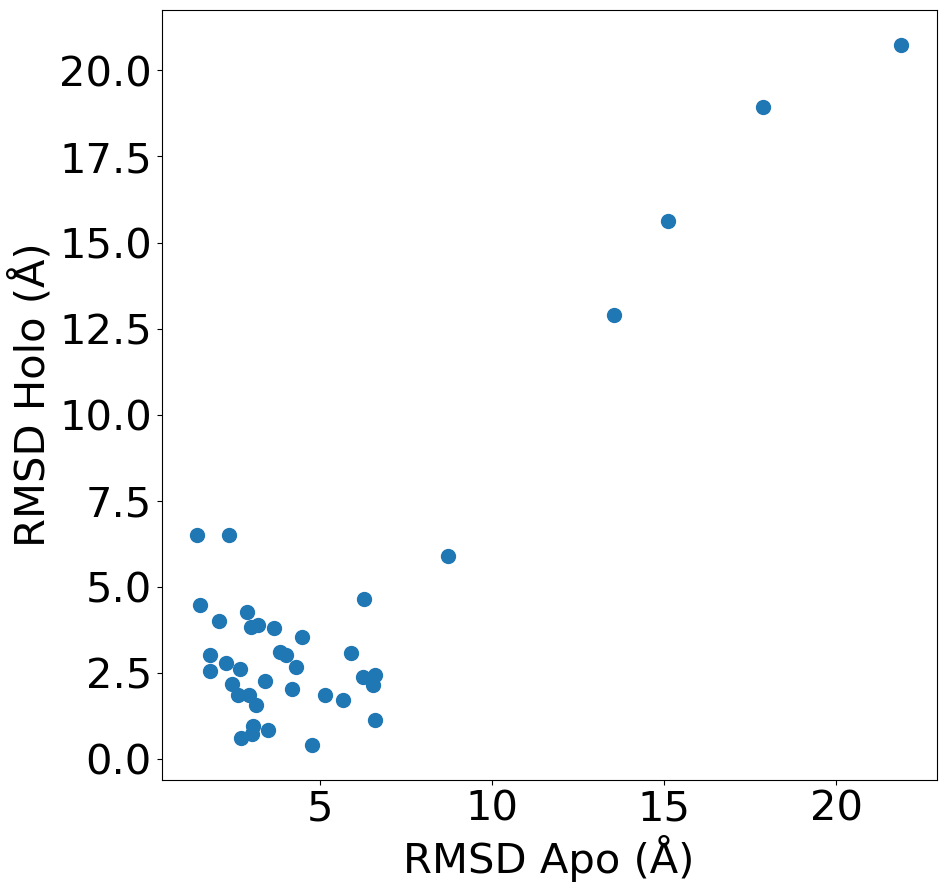

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.scatter(result_pair['RMSD'],result_pair['RMSD_pair'],s=100)
plt.xlabel('RMSD Apo (Å)',fontsize=30)
plt.ylabel('RMSD Holo (Å)',fontsize=30)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
#plt.savefig('RMSD.png')

In [19]:
AlphaFold_df=pd.read_csv('AlphaFold_RMSD.csv',index_col='ID')
AlphaFold_df=AlphaFold_df.drop(AlphaFold_df.columns[0], axis=1)

In [20]:
AlphaFold_df['RMSD_Fold'] = pd.to_numeric(AlphaFold_df['RMSD_Fold'], errors='coerce')

In [21]:
AlphaFold_df=AlphaFold_df.dropna()

In [22]:
AlphaFold_dict=AlphaFold_df.to_dict()['RMSD_Fold']

In [23]:
result_pair.dtypes

ID            object
RMSD         float64
ID_pair       object
RMSD_pair    float64
dtype: object

In [24]:
AlphaFold_df.dtypes

RMSD_Fold    float64
dtype: object

In [25]:
for index, i in result_pair.iterrows():
    result_pair.loc[index,'RMSD']-=AlphaFold_dict[i['ID']]
    result_pair.loc[index,'RMSD_pair']-=AlphaFold_dict[i['ID_pair']]

(array([-4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.]),
 [Text(-4.0, 0, '−4'),
  Text(-3.0, 0, '−3'),
  Text(-2.0, 0, '−2'),
  Text(-1.0, 0, '−1'),
  Text(0.0, 0, '0'),
  Text(1.0, 0, '1'),
  Text(2.0, 0, '2'),
  Text(3.0, 0, '3'),
  Text(4.0, 0, '4'),
  Text(5.0, 0, '5')])

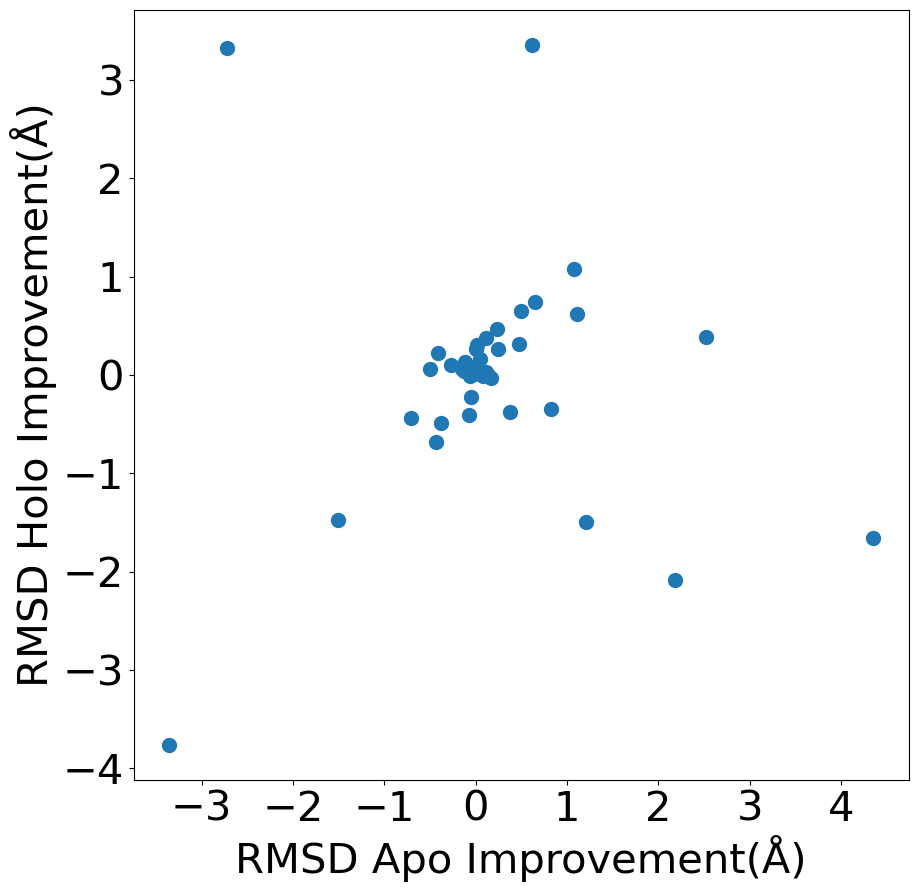

In [26]:
plt.figure(figsize=(10,10))
plt.scatter(result_pair['RMSD'],result_pair['RMSD_pair'],s=100)
plt.xlabel('RMSD Apo Improvement(Å)',fontsize=30)
plt.ylabel('RMSD Holo Improvement(Å)',fontsize=30)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)

In [27]:
result_pair['RMSD_sum']=result_pair['RMSD']+result_pair['RMSD_pair']

In [28]:
result_pair.sort_values('RMSD_sum')

,ID,RMSD,ID_pair,RMSD_pair,RMSD_sum
28,4AKE_B,-3.357762,2ECK_B,-3.759513,-7.117275
25,1FMF-4_A,-1.511834,1ID8-11_A,-1.478940,-2.990774
6,1TJD_A,-0.712956,1EEJ_B,-0.441966,-1.154923
27,2L50-24_A,-0.429687,2L51-15_B,-0.681335,-1.111022
10,1NTR-7_A,-0.378808,1KRX-4_A,-0.487784,-0.866592
15,1JFJ-3_A,-0.071992,1JFK_A,-0.402335,-0.474327
16,1LIP-2_A,-0.495849,1JTB-6_A,0.065737,-0.430112
18,2RCS_H,1.211920,1AJ7_H,-1.491750,-0.279830
39,1MUT-11_A,-0.051301,1PUN-7_A,-0.226884,-0.278185
22,2NLN-4_A,-0.414035,1RRO_A,0.223240,-0.190795
